# Heterogeneity in Sarcopenic Obesity: Clinical and Biochemical Profiling
This notebook implements the machine learning pipeline with Explainable AI (SHAP) to reveal clinical patterns underlying different sarcopenic obesity definitions.

### Features:
- Diagnostic Parity: Analyzes Simple 1, Simple 2, and Combined definitions.
- Result Persistence: Saves SHAP beeswarm/bar plots and metric summaries to the `results/` folder.

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, cohen_kappa_score,
    confusion_matrix, accuracy_score, precision_score, f1_score
)

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

DATA_DIR = Path("../../data")
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
def clean_numeric(series):
    """Converts a series to numeric after replacing commas with dots."""
    if series.dtype != object:
        return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(series.astype(str).str.replace(',', '.', regex=False).str.strip(), errors='coerce')

def is_sarcopenic_proxy(row):
    """Calf Circumference (CC) thresholds: 34cm (M), 33cm (F)."""
    if pd.isna(row['CIRCPANTORRILLA19_1']): return np.nan
    if row['SEXO'] == 1:
        return 1 if row['CIRCPANTORRILLA19_1'] < 34 else 0
    else:
        return 1 if row['CIRCPANTORRILLA19_1'] < 33 else 0

def calculate_biomarkers(df):
    """Estimates ASM (Lee) and BFP (Gallagher)."""
    sex_idx = (df['SEXO'] == 1).astype(int)
    height_m = df['HEIGHT_FINAL'] / 100.0
    df['ASM'] = (0.244 * df['WEIGHT_FINAL']) + (7.8 * height_m) + (6.6 * sex_idx) - (0.098 * df['EDAD']) - 3.3
    df['ASMI'] = df['ASM'] / (height_m ** 2)
    df['BMI'] = df['WEIGHT_FINAL'] / (height_m ** 2)
    df['BFP'] = 63.7 - 86.4 * (1.0 / df['BMI']) + 12.1 * sex_idx + 0.12 * df['EDAD']
    return df

In [3]:
def run_analysis_for_target(df, target_col):
    """Executes ML analysis with tuning, saved plots, and metrics."""
    print(f"\nProcessing Target: {target_col}")
    df_valid = df.dropna(subset=[target_col]).copy()
    if df_valid.shape[0] < 50 or df_valid[target_col].nunique() < 2: return None

    numeric_features = ['EDAD', 'BMI', 'CINTURA21_1', 'CIRCPANTORRILLA19_1', 'CRP', 'FERRITINA', 'HCST', 'VIT_B12', 'VIT_D']
    categorical_features = ['SEXO', 'ENT', 'REGION']
    features_in = [f for f in numeric_features + categorical_features if f in df_valid.columns]
    
    X = df_valid[features_in]; y = df_valid[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    preprocessor = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), [f for f in numeric_features if f in features_in]),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), [f for f in categorical_features if f in features_in])
    ])

    models_config = {
        'XGBoost': (XGBClassifier(random_state=42), {'model__n_estimators': [100], 'model__learning_rate': [0.1]}),
        'LightGBM': (LGBMClassifier(verbose=-1, random_state=42, class_weight='balanced'), {'model__num_leaves': [31]}),
        'RandomForest': (RandomForestClassifier(random_state=42, class_weight='balanced'), {'model__n_estimators': [100]}),
        'AdaBoost': (AdaBoostClassifier(random_state=42), {'model__n_estimators': [50, 100]})
    }

    results = []; best_auc = -1; best_model = None; best_name = ""
    for name, (clf, params) in tqdm(models_config.items(), desc=f"Models for {target_col}", leave=False):
        start_time = time.time()
        pipe = Pipeline([('prep', preprocessor), ('model', clf)])
        search = RandomizedSearchCV(pipe, params, n_iter=2, cv=3, scoring='roc_auc', n_jobs=2, random_state=42)
        search.fit(X_train, y_train)
        
        duration = time.time() - start_time
        y_prob = search.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        res = {
            'Target': target_col, 'Model': name,
            'Accuracy': accuracy_score(y_test, search.predict(X_test)),
            'ROC_AUC': auc, 'PR_AUC': average_precision_score(y_test, y_prob),
            'Time_Sec': round(duration, 2)
        }
        results.append(res)
        if auc > best_auc: best_auc = auc; best_model = search.best_estimator_; best_name = name

    # --- SHAP XAI ---
    X_test_trans = best_model.named_steps['prep'].transform(X_test)
    if hasattr(X_test_trans, "toarray"): X_test_trans = X_test_trans.toarray()
    f_names = best_model.named_steps['prep'].get_feature_names_out()
    X_sample = pd.DataFrame(X_test_trans, columns=f_names).sample(min(300, len(X_test)), random_state=42)
    
    explainer = shap.Explainer(best_model.named_steps['model'].predict_proba, X_sample)
    shap_ex = explainer(X_sample)
    shap_values = shap_ex[:,:,1] if len(shap_ex.shape) == 3 else shap_ex

    # Save & Show Beeswarm
    plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(shap_values, show=False)
    plt.title(f"Clinical Profile: {target_col} ({best_name})")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"shap_beeswarm_{target_col}.png"); plt.show()
    
    return pd.DataFrame(results)


Processing Target: SO_SIMP_1


Models for SO_SIMP_1:   0%|          | 0/4 [00:00<?, ?it/s]

PermutationExplainer explainer: 301it [01:01,  4.88it/s]                         


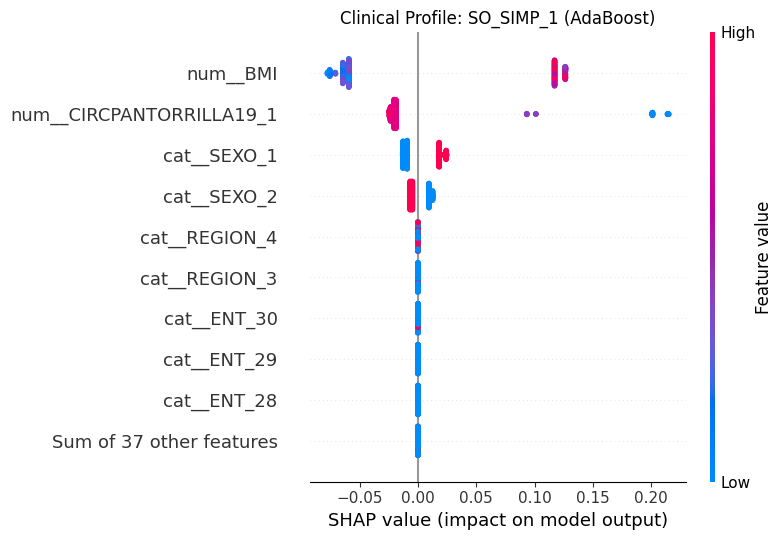


Processing Target: SO_SIMP_2


Models for SO_SIMP_2:   0%|          | 0/4 [00:00<?, ?it/s]

PermutationExplainer explainer: 301it [01:19,  3.41it/s]                         


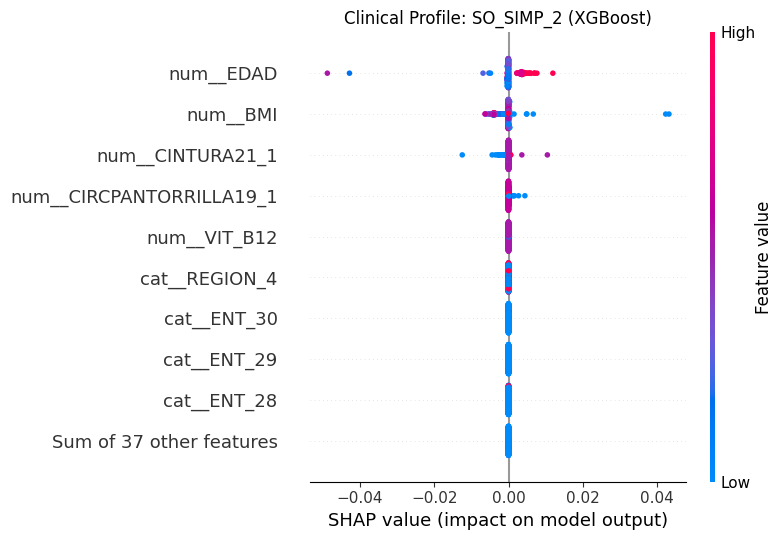


Processing Target: SO_COMBINED


Models for SO_COMBINED:   0%|          | 0/4 [00:00<?, ?it/s]

PermutationExplainer explainer: 301it [01:12,  3.56it/s]                         


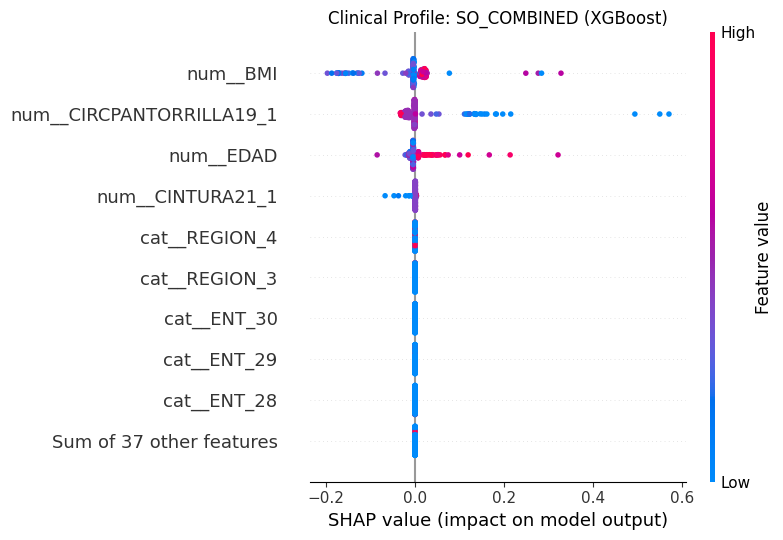


✅ Metrics saved to results/


In [4]:
df = pd.read_csv(DATA_DIR / "ensanut_integrated.csv", low_memory=False)
df.columns = [c.upper() for c in df.columns]
cols = ['WEIGHT_FINAL', 'HEIGHT_FINAL', 'CINTURA21_1', 'CIRCPANTORRILLA19_1', 'SEXO', 'EDAD', 'ENT', 'REGION', 'CRP', 'FERRITINA', 'HCST', 'VIT_B12', 'VIT_D']
for col in cols: 
    if col in df.columns: df[col] = clean_numeric(df[col])

df = df.dropna(subset=['WEIGHT_FINAL', 'HEIGHT_FINAL', 'EDAD', 'SEXO']).copy()
df = calculate_biomarkers(df)

# Definitions
df['SO_SIMP_1'] = ((df['BMI'] >= 30) & (df.apply(is_sarcopenic_proxy, axis=1) == 1)).astype(float)
df['SO_SIMP_2'] = ((((df['SEXO'] == 1) & (df['CINTURA21_1'] >= 90)) | ((df['SEXO'] == 2) & (df['CINTURA21_1'] >= 80))) & \
                   (((df['SEXO'] == 1) & (df['ASMI'] < 7.0)) | ((df['SEXO'] == 2) & (df['ASMI'] < 5.7)))).astype(float)
df['SO_COMBINED'] = ((df['SO_SIMP_1'] == 1) | (df['SO_SIMP_2'] == 1)).astype(float)

all_metrics = []
for t in ['SO_SIMP_1', 'SO_SIMP_2', 'SO_COMBINED']:
    res = run_analysis_for_target(df, t)
    if res is not None: all_metrics.append(res)

if all_metrics:
    final_df = pd.concat(all_metrics)
    final_df.to_csv(RESULTS_DIR / "ml_results_summary.csv", index=False)
    print(f"\n✅ Metrics saved to {RESULTS_DIR}/")

In [5]:
import session_info

session_info.show(std_lib=True, dependencies=True)